# Classification and Regression, Part 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sktime.transformations.panel.reduce import Tabularizer

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring
from skorch.dataset import ValidSplit
from sklearn.metrics import accuracy_score
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from torch.optim.lr_scheduler import ReduceLROnPlateau


## Load the data

#### Classification

In [3]:
from sktime.datasets import load_gunpoint

In [4]:
X_gunpoint, y_gunpoint = load_gunpoint(return_X_y=True, return_type="numpy3D")
X_gunpoint.shape, y_gunpoint.shape

((200, 1, 150), (200,))

In [5]:
np.unique(y_gunpoint, return_counts=True)

(array(['1', '2'], dtype='<U1'), array([100, 100]))

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
y_gunpoint = le.fit_transform(y_gunpoint)

In [8]:
np.unique(y_gunpoint, return_counts=True)

(array([0, 1]), array([100, 100]))

#### Regression

In [9]:
X_covid = np.load("data/X_covid.npy")
y_covid = np.load("data/y_covid.npy")
X_covid.shape, y_covid.shape

((201, 1, 84), (201,))

## Split the data

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_gunpoint_train, X_gunpoint_test, y_gunpoint_train, y_gunpoint_test = train_test_split(X_gunpoint, y_gunpoint, random_state=0)
X_gunpoint_train.shape, X_gunpoint_test.shape, y_gunpoint_train.shape, y_gunpoint_test.shape

((150, 1, 150), (50, 1, 150), (150,), (50,))

In [12]:
X_train_covid, X_test_covid, y_train_covid, y_test_covid = train_test_split(X_covid, y_covid, random_state=0)
X_train_covid.shape, X_test_covid.shape, y_train_covid.shape, y_test_covid.shape

((150, 1, 84), (51, 1, 84), (150,), (51,))

## Deep Learning based

### MLP

#### Classification

In [13]:
from sklearn.neural_network import MLPClassifier

In [14]:
mlp = Tabularizer() * MLPClassifier(random_state=0)

In [15]:
mlp.fit(X_gunpoint_train, y_gunpoint_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


SklearnClassifierPipeline(classifier=MLPClassifier(random_state=0),
                          transformers=[Tabularizer()])

In [16]:
mlp.score(X_gunpoint_test, y_gunpoint_test)

0.98

#### Regression

In [17]:
from sklearn.neural_network import MLPRegressor

In [18]:
mlp = Tabularizer() * MLPRegressor(random_state=0, verbose=True)

In [19]:
mlp.fit(X_train_covid, y_train_covid)

Iteration 1, loss = 119901.71504296
Iteration 2, loss = 73789.36936212
Iteration 3, loss = 40342.14866093
Iteration 4, loss = 18901.53253307
Iteration 5, loss = 7257.18181857
Iteration 6, loss = 3694.82822453
Iteration 7, loss = 5967.27812827
Iteration 8, loss = 11200.74335727
Iteration 9, loss = 16506.50087990
Iteration 10, loss = 19915.56306820
Iteration 11, loss = 20735.24183149
Iteration 12, loss = 19201.77849948
Iteration 13, loss = 16027.60798883
Iteration 14, loss = 12161.52230790
Iteration 15, loss = 8113.06889324
Iteration 16, loss = 4691.02362060
Iteration 17, loss = 2359.80159588
Iteration 18, loss = 1207.02592033
Iteration 19, loss = 1137.63851692
Iteration 20, loss = 1845.38718976
Iteration 21, loss = 2937.13491876
Iteration 22, loss = 4035.56723783
Iteration 23, loss = 4848.22007688
Iteration 24, loss = 5193.99412689
Iteration 25, loss = 5009.25476979
Iteration 26, loss = 4348.85029535
Iteration 27, loss = 3382.22773781
Iteration 28, loss = 2332.13884314
Iteration 29, los

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


SklearnRegressorPipeline(regressor=MLPRegressor(random_state=0, verbose=True),
                         transformers=[Tabularizer()])

In [20]:
mlp.score(X_test_covid, y_test_covid)

-530996.4918941149

### CNN

In [21]:
from sktime.classification.deep_learning import CNNClassifier

In [21]:
# !pip install sktime[dl]
# !pip install tensorflow

In [22]:
cnn = CNNClassifier(n_conv_layers=2, random_state=0, verbose=True, n_epochs=100)

In [23]:
cnn.fit(X_gunpoint_train, y_gunpoint_train)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 144, 6)         │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 48, 6)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 42, 12)         │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 14, 12)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 168)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 902 (3.52 KB)

 Trainable params: 902 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4415 - loss: 0.7120  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4888 - loss: 0.7021 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6373 - loss: 0.6746 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7857 - loss: 0.6500 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7857 - loss: 0.6098 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7759 - loss: 0.5636 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7857 - loss: 0.5200 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7882 - loss: 0.4793 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7970 - loss: 0.4463 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7951 - loss: 0.4170 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8380 - loss: 0.3903 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

CNNClassifier(n_epochs=100, random_state=0, verbose=True)

In [24]:
cnn.score(X_gunpoint_test, y_gunpoint_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


1.0

In [40]:
cnn.history.history.keys()

dict_keys(['accuracy', 'loss'])

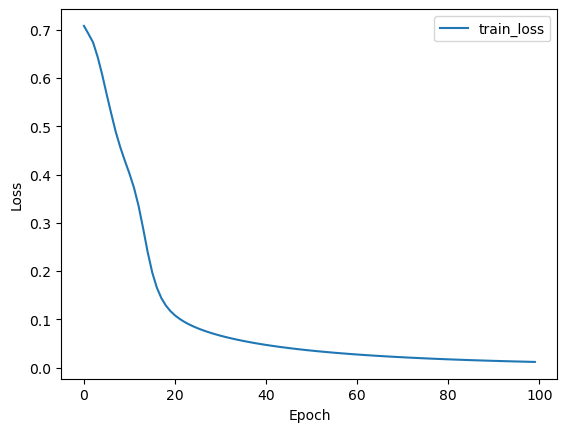

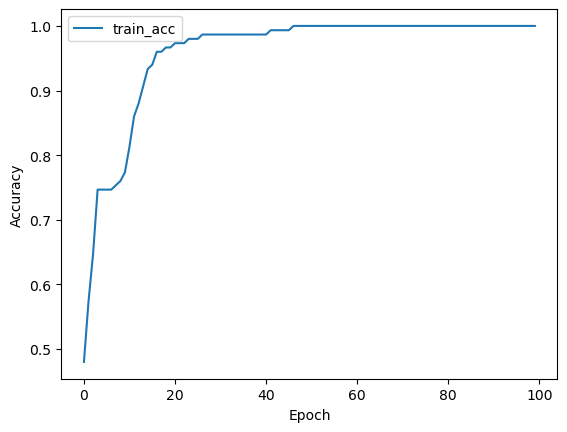

In [41]:
history = cnn.history.history
plt.plot(history['loss'], label='train_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history["accuracy"], label='train_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#### Skorch

In [42]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [124]:
class Conv1DClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(output_size=1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        x shape: (batch_size, in_channels, sequence_length)
        """
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [125]:
cnn = NeuralNetClassifier(
    Conv1DClassifier,
    module__in_channels=X_gunpoint_train.shape[1],
    module__num_classes=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=300,
    batch_size=128,
    lr=1e-4,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=0.2, stratified=True)
)
cnn

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.Conv1DClassifier'>,
  module__in_channels=1,
  module__num_classes=2,
)

In [126]:
cnn.fit(X_gunpoint_train.astype(np.float32), y_gunpoint_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.3250        0.7017       0.5000        0.6946     +  0.0654
      2       0.5417        0.6942       0.5000        0.6948        0.0149
      3       0.5917        0.6871       0.5000        0.6947        0.0165
      4       0.6333        0.6805       0.5000        0.6947        0.0162
      5       0.6500        0.6745       0.5000        0.6939        0.0151
      6       0.6500        0.6690       0.5000        0.6930        0.0167
      7       0.6667        0.6639       0.5000        0.6921        0.0162
      8       0.6667        0.6591       0.5000        0.6913        0.0173
      9       0.6667        0.6546       0.5000        0.6904        0.0167
     10       0.6750        0.6503       0.5000        0.6896        0.0176
     11       0.6833        0.6461       0.5000        0.6886        0.0161
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Conv1DClassifier(
    (features): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
    )
    (pool): AdaptiveAvgPool1d(output_size=1)
    (classifier): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=128, out_features=2, bias=True)
    )
  ),
)

In [127]:
y_pred = cnn.predict(X_gunpoint_test.astype(np.float32))
accuracy_score(y_gunpoint_test, y_pred)

1.0

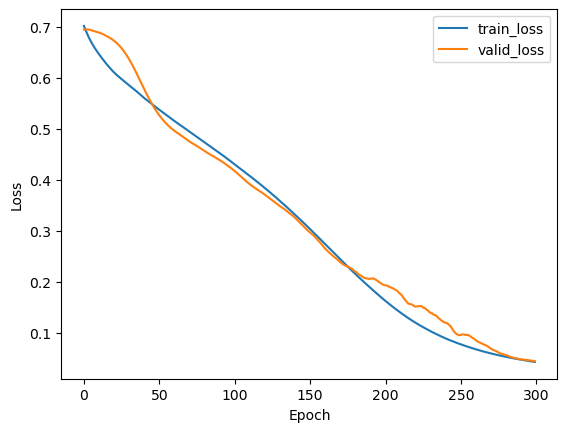

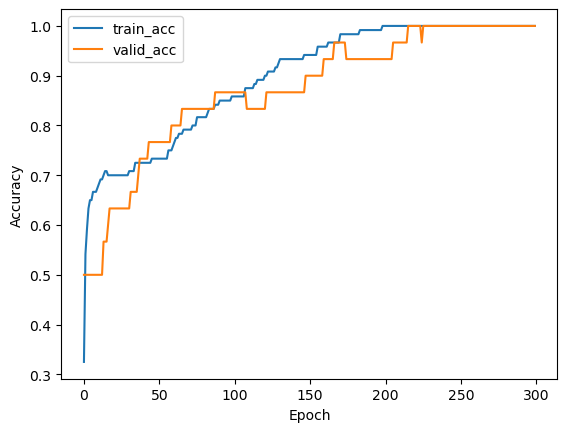

In [128]:
history = cnn.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### RNN

In [49]:
from sktime.classification.deep_learning import SimpleRNNClassifier

In [50]:
rnn = SimpleRNNClassifier(random_state=0, verbose=True)

In [51]:
rnn.fit(X_gunpoint_train, y_gunpoint_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56 (224.00 B)

 Trainable params: 56 (224.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5235 - loss: 0.2811 - learning_rate: 0.0010
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5772 - loss: 0.2535 - learning_rate: 0.0010
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5750 - loss: 0.2520 - learning_rate: 0.0010
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5710 - loss: 0.2514 - learning_rate: 0.0010
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5645 - loss: 0.2510 - learning_rate: 0.0010
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5662 - loss: 0.2502 - learning_rate: 0.0010
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5750 - loss: 0.2499 - learning_rate: 0.0010
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5786 - loss: 0.2499 - learning_rate: 0.0010
Epoch 9/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5758 - loss: 0.2498 - learning_rate: 0.0010
E

SimpleRNNClassifier(verbose=True)

In [52]:
rnn.score(X_gunpoint_test, y_gunpoint_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.5

In [53]:
rnn.summary().keys()

dict_keys(['accuracy', 'loss', 'learning_rate'])

In [54]:
rnn.summary()

{'accuracy': [0.4866666793823242,
  0.5133333206176758,
  0.47333332896232605,
  0.46666666865348816,
  0.4533333480358124,
  0.4533333480358124,
  0.46666666865348816,
  0.47333332896232605,
  0.46666666865348816,
  0.46666666865348816,
  0.46666666865348816,
  0.46666666865348816,
  0.46666666865348816,
  0.47999998927116394,
  0.4866666793823242,
  0.4866666793823242,
  0.4866666793823242,
  0.47999998927116394,
  0.47999998927116394,
  0.47999998927116394,
  0.47999998927116394,
  0.47999998927116394,
  0.47999998927116394,
  0.47999998927116394,
  0.4866666793823242,
  0.4866666793823242,
  0.4866666793823242,
  0.4933333396911621,
  0.4933333396911621,
  0.4933333396911621,
  0.4933333396911621,
  0.4866666793823242,
  0.4866666793823242,
  0.47333332896232605,
  0.47999998927116394,
  0.47999998927116394,
  0.47999998927116394,
  0.4866666793823242,
  0.4866666793823242,
  0.4866666793823242,
  0.4866666793823242,
  0.4866666793823242,
  0.47999998927116394,
  0.4799999892711639

### LSTM

In [117]:
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [118]:
# build a vanilla RNN with a classification head

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.swapaxes(x, 1, 2)  # swap the last two dimensions to match RNN input shape
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # take the last output of the sequence
        out = self.fc(out)
        return out

In [119]:
lstm = NeuralNetClassifier(
    LSTM,
    module__input_size=X_gunpoint_train.shape[1],
    module__hidden_size=64,
    module__output_size=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=500,
    batch_size=32,
    lr=1e-4,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=5, stratified=True)
)
lstm

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.LSTM'>,
  module__hidden_size=64,
  module__input_size=1,
  module__output_size=2,
)

In [120]:
lstm.fit(X_gunpoint_train.astype(np.float32), y_gunpoint_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.4917        0.6955       0.5000        0.6944     +  0.1399
      2       0.4917        0.6953       0.5000        0.6943        0.0955
      3       0.4917        0.6951       0.5000        0.6942        0.0733
      4       0.4917        0.6950       0.5000        0.6942        0.0840
      5       0.4917        0.6949       0.5000        0.6941        0.1034
      6       0.4917        0.6948       0.5000        0.6940        0.1084
      7       0.4917        0.6946       0.5000        0.6940        0.0997
      8       0.4917        0.6946       0.5000        0.6939        0.0741
      9       0.4917        0.6945       0.5000        0.6938        0.0827
     10       0.4917        0.6944       0.5000        0.6938        0.1006
     11       0.4917        0.6943       0.5000        0.6937        0.1144
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTM(
    (rnn): LSTM(1, 64, batch_first=True)
    (fc): Linear(in_features=64, out_features=2, bias=True)
  ),
)

In [121]:
y_pred = lstm.predict(X_gunpoint_test.astype(np.float32))
accuracy_score(y_gunpoint_test, y_pred)

0.64

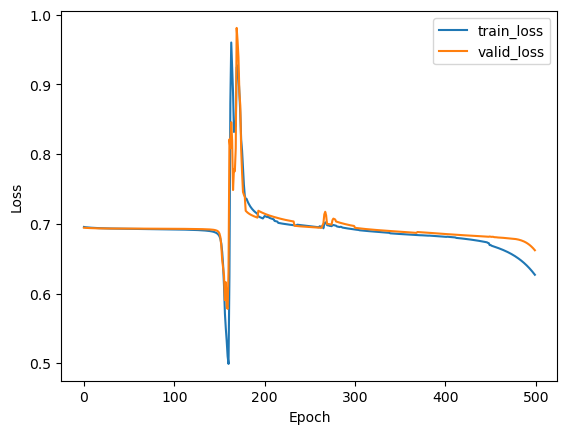

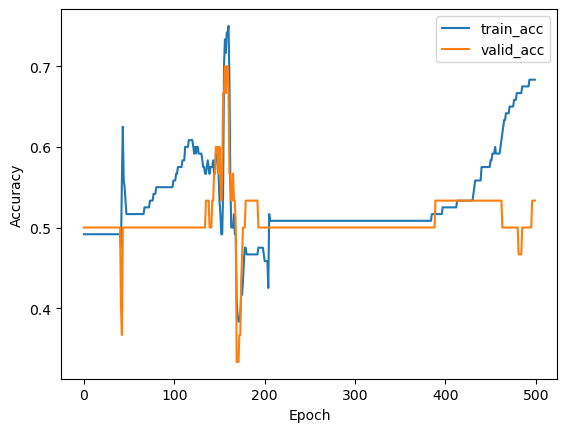

In [122]:
history = lstm.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### ResNet

In [70]:
from sktime.classification.deep_learning import ResNetClassifier

In [71]:
resnet = ResNetClassifier(n_epochs=10, random_state=0, verbose=True)

In [72]:
resnet.fit(X_gunpoint_train, y_gunpoint_train)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 150, 64)   │        576 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 150, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 150, 64)   │     20,544 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 150, 64)   │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 150, 64)   │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 150, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 150, 128)  │     65,664 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 150, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 150, 128)  │     82,048 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 150, 128)  │          0 │ batch_normalizat

 Total params: 506,818 (1.93 MB)

 Trainable params: 504,258 (1.92 MB)

 Non-trainable params: 2,560 (10.00 KB)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.4763 - loss: 1.1951
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7362 - loss: 0.5622
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7077 - loss: 0.5196
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8288 - loss: 0.4016
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9248 - loss: 0.3191
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9036 - loss: 0.2759
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8970 - loss: 0.2546
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8490 - loss: 0.2944
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9584 - loss: 0.2019
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9535 - loss: 0.1608


ResNetClassifier(n_epochs=10, random_state=0, verbose=True)

In [73]:
resnet.score(X_gunpoint_test, y_gunpoint_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


0.5

### InceptionTime

In [74]:
from sktime.classification.deep_learning import InceptionTimeClassifier

In [75]:
inception = InceptionTimeClassifier(random_state=0, verbose=True, n_epochs=10)

In [76]:
inception.fit(X_gunpoint_train, y_gunpoint_train)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 1)    │          0 │ input_layer_3[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 150, 32)   │      1,280 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 150, 32)   │        640 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 150, 32)   │        320 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 150, 32)   │         32 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150, 128)  │          0 │ conv1d_13[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_14[0][0],  │
│                     │                   │            │ conv1d_15[0][0],  │
│                     │                   │            │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 150, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 150, 32)   │      4,096 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 150, 128)  │          0 │ activation_9[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 150, 32)   │     40,960 │ conv1d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 150, 32)   │     20,480 │ conv1d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 150, 32)   │     10,240 │ conv1d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 150, 32)   │      4,096 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 150, 128)  │          0 │ conv1d_18[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_19[0][0],  │
│                     │                   │            │ conv1d_20[0][0],  │
│                     │                   │            │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 150, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 422,498 (1.61 MB)

 Trainable params: 420,450 (1.60 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5317 - loss: 0.8970 - learning_rate: 0.0010
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7971 - loss: 0.4281 - learning_rate: 0.0010
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9624 - loss: 0.2283 - learning_rate: 0.0010
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9855 - loss: 0.1042 - learning_rate: 0.0010
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9855 - loss: 0.0575 - learning_rate: 0.0010
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 1.0000 - loss: 0.0346 - learning_rate: 0.0010
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 1.0000 - loss: 0.0233 - learning_rate: 0.0010
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 1.0000 - loss: 0.0157 - learning_rate: 0.0010
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 1.0000 - loss: 0.0151 - learning_rate: 0.0010
Epoch 10/10
3/3 ━━━━━━━━━━━━

InceptionTimeClassifier(n_epochs=10, random_state=0, verbose=True)

In [77]:
inception.score(X_gunpoint_test, y_gunpoint_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


0.72

### LSTM + FCN

In [78]:
from sktime.classification.deep_learning import LSTMFCNClassifier

In [79]:
lstmfcn = LSTMFCNClassifier(n_epochs=10, random_state=0, verbose=True)

In [80]:
lstmfcn.fit(X_gunpoint_train, y_gunpoint_train)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 150, 128)  │      1,152 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 150, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 150, 256)  │    164,096 │ activation_17[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 256)  │      1,024 │ conv1d_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 150, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, 150, 128)  │     98,432 │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 1, 150)    │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_46[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 8)         │      5,088 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 150, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_19[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 136)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │        274 │ concatenate_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 271,090 (1.03 MB)

 Trainable params: 270,066 (1.03 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5159 - loss: 0.7421
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6992 - loss: 0.5798 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7240 - loss: 0.5544 
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7285 - loss: 0.5423 
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7470 - loss: 0.5082 
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7311 - loss: 0.4882 
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7355 - loss: 0.4820 
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7964 - loss: 0.4511 
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7426 - loss: 0.4463 
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7752 - loss: 0.4243 


LSTMFCNClassifier(n_epochs=10, random_state=0, verbose=True)

In [81]:
lstmfcn.score(X_gunpoint_test, y_gunpoint_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


0.7

### TapNet

In [82]:
from sktime.classification.deep_learning import TapNetClassifier

In [52]:
# !pip install keras-self-attention

In [83]:
tapnet = TapNetClassifier(random_state=0, verbose=True, n_epochs=10)

In [84]:
%%time
tapnet.fit(X_gunpoint_train, y_gunpoint_train)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 150, 1)    │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 150, 1)    │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_47 (Conv1D)  │ (None, 150, 256)  │      2,304 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 150, 256)  │      2,304 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 150, 1)    │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 256)  │      1,024 │ conv1d_47[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 256)  │      1,024 │ conv1d_50[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_53 (Conv1D)  │ (None, 150, 256)  │      2,304 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 150, 256)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 150, 256)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 256)  │      1,024 │ conv1d_53[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 150, 256)  │    524,544 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_51 (Conv1D)  │ (None, 150, 256)  │    524,544 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 150, 256)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 256)  │      1,024 │ conv1d_48[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 256)  │      1,024 │ conv1d_51[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_54 (Conv1D)  │ (None, 150, 256)  │    524,544 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 150, 256)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 150, 256)  │          0 │ batch_normalizat

 Total params: 2,916,542 (11.13 MB)

 Trainable params: 2,911,702 (11.11 MB)

 Non-trainable params: 4,840 (18.91 KB)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.5016 - loss: 5.0530
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.7918 - loss: 1.4162
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.8881 - loss: 0.9515
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.8976 - loss: 0.7730
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.9577 - loss: 0.2217
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.9340 - loss: 0.1735
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.9686 - loss: 0.1477
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.9704 - loss: 0.1198
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.9690 - loss: 0.1037
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.9747 - loss: 0.0886
CPU times: user 1min 23s, sys: 14.3 s, total: 1min 37s
Wall time: 21.4 s


TapNetClassifier(n_epochs=10, random_state=0, verbose=True)

In [85]:
tapnet.score(X_gunpoint_test, y_gunpoint_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step


0.56

## Kernel-based

In [86]:
from sktime.classification.kernel_based import RocketClassifier

In [96]:
%%time
rocket = RocketClassifier(random_state=0, rocket_transform="rocket")
rocket.fit(X_gunpoint_train, y_gunpoint_train)
rocket.score(X_gunpoint_test, y_gunpoint_test)

CPU times: user 12 s, sys: 198 ms, total: 12.2 s
Wall time: 10.5 s


0.52

In [88]:
%%time
rocket = RocketClassifier(random_state=0, rocket_transform="minirocket")
rocket.fit(X_gunpoint_train, y_gunpoint_train)
rocket.score(X_gunpoint_test, y_gunpoint_test)

CPU times: user 4.86 s, sys: 600 ms, total: 5.46 s
Wall time: 2.55 s


0.52

In [59]:
# %%time
## slow
# rocket = RocketClassifier(random_state=0, rocket_transform="multirocket")
# rocket.fit(X_gunpoint_train, y_gunpoint_train)
# rocket.score(X_gunpoint_test, y_gunpoint_test)

#### Aeon

In [ ]:
# !pip install aeon

In [89]:
from aeon.classification.convolution_based import MiniRocketClassifier, MultiRocketHydraClassifier

In [90]:
clf = MiniRocketClassifier(n_jobs=-1)

In [91]:
clf.fit(X_gunpoint_train, y_gunpoint_train)

MiniRocketClassifier(n_jobs=-1)

In [92]:
clf.score(X_gunpoint_test, y_gunpoint_test)

1.0

In [93]:
clf = MultiRocketHydraClassifier(n_jobs=-1)

In [94]:
clf.fit(X_gunpoint_train, y_gunpoint_train)

MultiRocketHydraClassifier(n_jobs=-1)

In [95]:
clf.score(X_gunpoint_test, y_gunpoint_test)

1.0

## Ensemble Hybrid


In [60]:
from sktime.classification.hybrid import HIVECOTEV2

In [61]:
# %%time
# # slow
# hivecote = HIVECOTEV2(random_state=0)
# hivecote.fit(X_gunpoint_train, y_gunpoint_train)
# hivecote.score(X_gunpoint_test, y_gunpoint_test)

Some newer models are available only in the AEON library https://www.aeon-toolkit.org/en/stable/index.html. The syntax is the same as sktime.

# XAI

### Integrated Gradients

In [164]:
# !pip install captum

import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients
from captum.attr import GradientShap

In [167]:
instance_idx = 1

cnn.module_.to("cpu")

ig = IntegratedGradients(cnn.module_)

x = torch.as_tensor(
    X_gunpoint_train[instance_idx:instance_idx+1, :, :],
    dtype=torch.float32,
    device="cpu"
)

target = int(y_gunpoint_train[instance_idx])

baseline = torch.zeros_like(x, device="cpu")
baseline = torch.as_tensor(
    X_gunpoint_train.mean(axis=0, keepdims=True),
    dtype=torch.float32,
    device="cpu"
)

attributions = ig.attribute(
    inputs=x,
    baselines=baseline,
    target=target
)

attributions = attributions.detach().cpu().numpy()

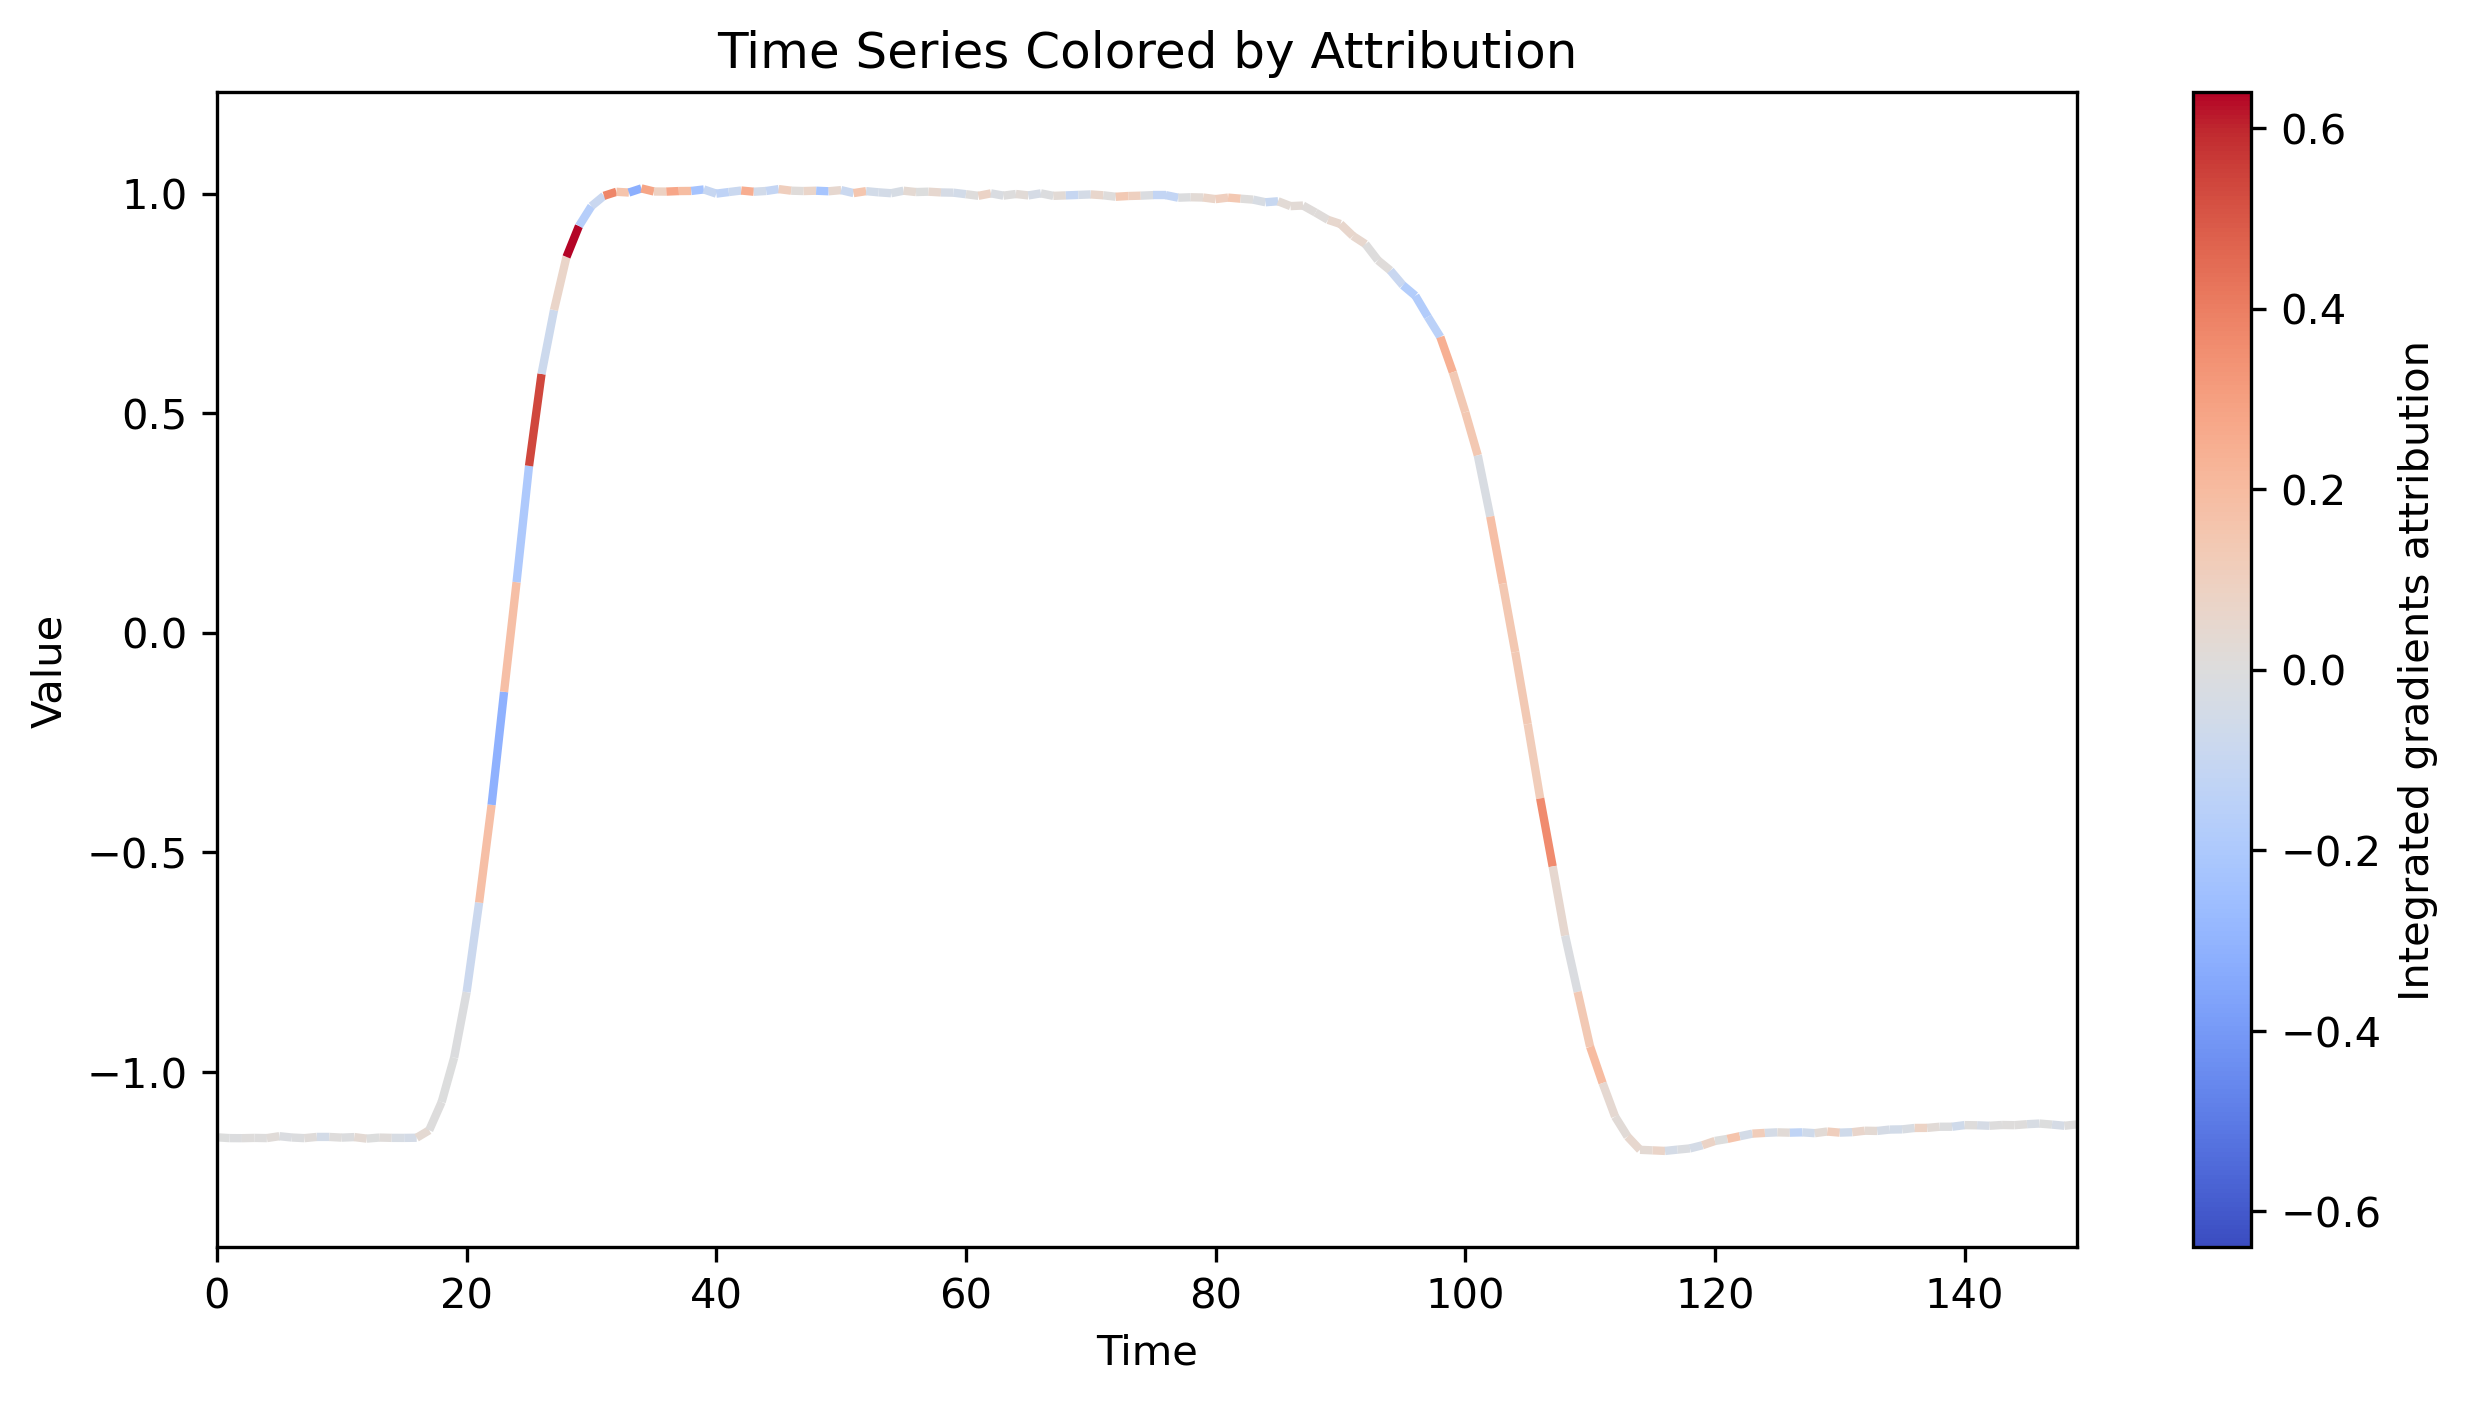

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

ts = X_gunpoint_train[0, 0, :]

attr = attributions[0, 0, :]   # first instance, first channel

x_axis = np.arange(len(ts))

points = np.array([x_axis, ts]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

vmax = np.max(np.abs(attr))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(dpi=300, figsize=(10, 5))

lc = LineCollection(
    segments,
    cmap="coolwarm",
    norm=norm,
    linewidth=2
)

# one attribution value per segment
lc.set_array(attr[:-1])

ax.add_collection(lc)

ax.set_xlim(x_axis.min(), x_axis.max())
ax.set_ylim(ts.min() - 0.1 * np.ptp(ts), ts.max() + 0.1 * np.ptp(ts))

cbar = plt.colorbar(lc, ax=ax)
cbar.set_label("Integrated gradients attribution")

ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("Time Series Colored by Attribution")

plt.show()

### Subsequences

In [99]:
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [100]:
trf = RandomShapeletTransform(n_shapelet_samples=100, random_state=0)
dt = DecisionTreeClassifier(random_state=0)

In [101]:
X_train_trf = trf.fit_transform(X_gunpoint_train, y_gunpoint_train)
X_test_trf = trf.transform(X_gunpoint_test)

In [102]:
dt.fit(X_train_trf, y_gunpoint_train)

DecisionTreeClassifier(random_state=0)

In [103]:
dt.score(X_test_trf, y_gunpoint_test)

0.94

In [104]:
shapelets = trf.shapelets

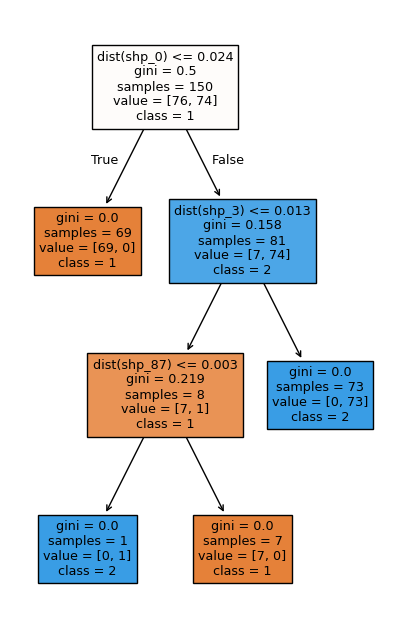

In [105]:
plt.figure(figsize=(5, 8))
plot_tree(dt, class_names=le.classes_, feature_names=[f"dist(shp_{i})" for i in range(X_train_trf.shape[1])], filled=True)
plt.show()

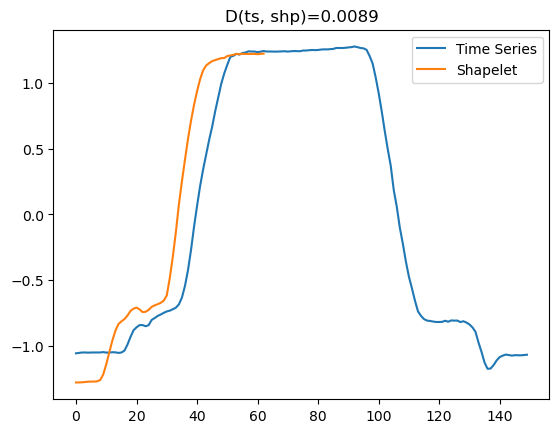

In [106]:
plt.plot(X_gunpoint_test[0, 0, :], label="Time Series")
plt.plot(shapelets[dt.tree_.feature[0]][-1], label="Shapelet")
plt.title(f"D(ts, shp)={np.round(X_test_trf.values[0, 0], 4)}")
plt.legend()
plt.show()

### Counterfactuals

In [107]:
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from scipy.spatial import distance_matrix

In [108]:
clf = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="euclidean")

In [109]:
clf.fit(X_gunpoint_train, y_gunpoint_train)

KNeighborsTimeSeriesClassifier(distance='euclidean')

In [110]:
clf.score(X_gunpoint_test, y_gunpoint_test)

0.92

In [111]:
y_pred = clf.predict(X_gunpoint_test)

In [112]:
x = X_gunpoint_test[0].ravel()
x_label = y_pred[0]

In [113]:
# take instances with a different predicted label w.r.t. x
counterfactuals_idxs = np.argwhere(y_pred != x_label).ravel()
counterfactuals = X_gunpoint_test[counterfactuals_idxs]

In [114]:
%%time
dist_x_counterfactuals = distance_matrix(x.reshape(1,-1), counterfactuals[:, 0, :])

CPU times: user 87 μs, sys: 39 μs, total: 126 μs
Wall time: 107 μs


In [115]:
# find the index of the closest one
closest_counterfactual_idx = np.argsort(dist_x_counterfactuals).ravel()[0]
closest_counterfactual_idx

14

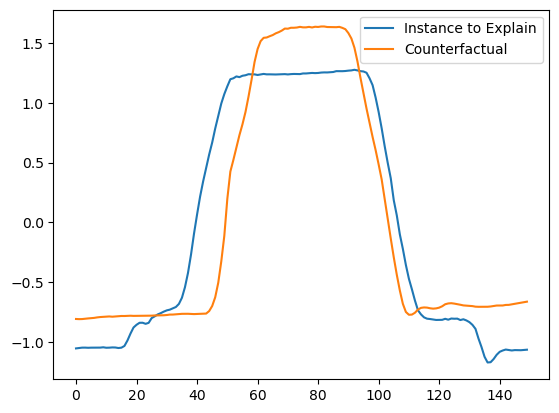

In [116]:
plt.plot(X_gunpoint_test[0, 0, :], label="Instance to Explain")
plt.plot(counterfactuals[closest_counterfactual_idx, 0, :], label="Counterfactual")
plt.legend()
plt.show()